In [1]:
# Importing the packages 
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None



# Read in the data
df = pd.read_csv(r'C:\Users\ODEIGAH HENRY\Downloads\movies.csv')

In [46]:
# Data Cleaning & Preprocessing
df_raw = pd.read_csv(r'C:\Users\ODEIGAH HENRY\Downloads\movies.csv')
print(f"\nRaw shape: {df_raw.shape}")


Raw shape: (7668, 15)


In [2]:
# Taking a look at the data
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
# Remove missing values
df = df.dropna()

In [41]:
# Data types for columns
print(df.dtypes)

name        float64
rating      float64
genre       float64
year          int64
released    float64
score       float64
votes       float64
director    float64
writer      float64
star        float64
country     float64
budget        int64
gross         int64
company     float64
runtime     float64
Year         object
dtype: object


In [48]:
print("\n[Missing values per column]")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(missing_df[missing_df["missing"] > 0].to_string())


[Missing values per column]
          missing   pct
rating         77   1.0
released        2   0.0
score           3   0.0
votes           3   0.0
writer          3   0.0
star            1   0.0
country         3   0.0
budget       2171  28.3
gross         189   2.5
company        17   0.2
runtime         4   0.1


In [49]:
df = df_raw.dropna(subset=["gross"]).copy()
print(f"\nRows after dropping missing gross: {len(df)} (removed {len(df_raw) - len(df)})")


Rows after dropping missing gross: 7479 (removed 189)


In [52]:
# Parse release year from 'released' column as a cross-check
df["release_year_parsed"] = (
    df["released"]
    .str.extract(r"(\d{4})")
    .astype(float)
)

In [55]:
# Fill missing budget with median per genre
df["budget"] = df.groupby("genre")["budget"].transform(
    lambda x: x.fillna(x.median())
)
# Remaining NaN budgets → overall median
df["budget"] = df["budget"].fillna(df["budget"].median())

In [56]:
# Filling other numeric NaNs with column median
for col in ["score", "votes", "runtime"]:
    df[col] = df[col].fillna(df[col].median())

In [57]:
# Standardise rating: anything not in common set → "Other"
valid_ratings = {"G", "PG", "PG-13", "R", "NC-17"}
df["rating"] = df["rating"].where(df["rating"].isin(valid_ratings), other="Other")
df["rating"] = df["rating"].fillna("Other")

In [59]:
#  Feature engineering
df["log_gross"]     = np.log1p(df["gross"])
df["log_budget"]    = np.log1p(df["budget"])
df["budget_ratio"]  = df["gross"] / (df["budget"] + 1)   # ROI proxy
df["votes_per_min"] = df["votes"] / (df["runtime"] + 1)  # engagement density

print("\n[Cleaned shape]:", df.shape)
print("\n[New features added]: log_gross, log_budget, budget_ratio, votes_per_min")


[Cleaned shape]: (7479, 20)

[New features added]: log_gross, log_budget, budget_ratio, votes_per_min


In [60]:
# Save cleaned CSV
clean_path = "movies_cleaned.csv"
df.to_csv(clean_path, index=False)
print(f"\nCleaned dataset saved → {clean_path}")



Cleaned dataset saved → movies_cleaned.csv


In [61]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,1980.0,17.665632,16.759950,2.473619,6306.122449
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,1980.0,17.890555,15.319588,13.078465,619.047619
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,1980.0,20.104066,16.705882,29.909724,9600.000000
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,1980.0,18.239801,15.068274,23.843861,2483.146067
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,1980.0,17.500541,15.607270,6.641056,1090.909091


In [62]:
# Create correct released year column
df['yearcorrect'] = df['released'].astype('str').str.extract(r'(\d{4})') 
#Extract 4 consecutive digits from the string (year)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,...,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,...,19000000.0,46998772.0,Warner Bros.,146.0,1980.0,17.665632,16.759950,2.473619,6306.122449,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,...,4500000.0,58853106.0,Columbia Pictures,104.0,1980.0,17.890555,15.319588,13.078465,619.047619,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,...,18000000.0,538375067.0,Lucasfilm,124.0,1980.0,20.104066,16.705882,29.909724,9600.000000,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,...,3500000.0,83453539.0,Paramount Pictures,88.0,1980.0,18.239801,15.068274,23.843861,2483.146067,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,...,6000000.0,39846344.0,Orion Pictures,98.0,1980.0,17.500541,15.607270,6.641056,1090.909091,1980


In [63]:
# Sorting by gross
df = df.sort_values(by=['gross'], inplace=False, ascending=False)
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,...,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,...,237000000.0,2.847246e+09,Twentieth Century Fox,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,356000000.0,2.797501e+09,Marvel Studios,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,...,200000000.0,2.201647e+09,Twentieth Century Fox,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,...,245000000.0,2.069522e+09,Lucasfilm,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,321000000.0,2.048360e+09,Marvel Studios,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,2018


In [64]:
# Drop any duplicates
df = df.drop_duplicates()


In [70]:
# Hypothesis:
# Budget has a high correlation with gross revenue
# Company has a high correlation with gross revenue

In [71]:
# 1. Look at Budget with gross revenue

<function matplotlib.pyplot.show(close=None, block=None)>

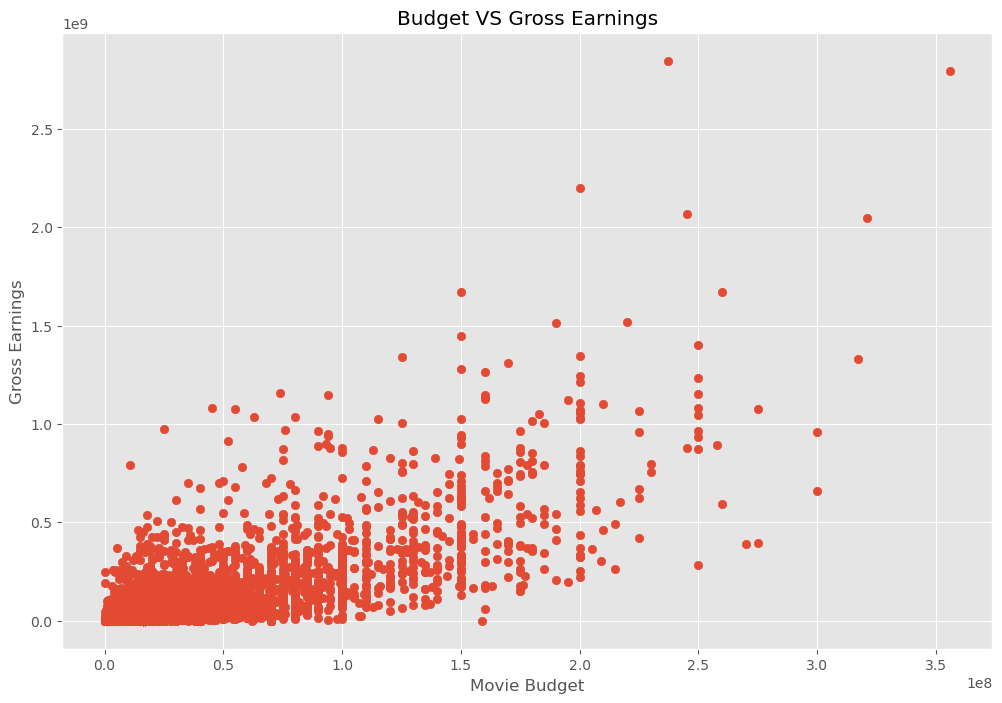

In [90]:
# Creating a scatter plot to show relationship between budget and gross earnings
plt.scatter(x=df['budget'],y=df['gross'])
plt.title('Budget VS Gross Earnings')
plt.xlabel ('Movie Budget')
plt.ylabel ('Gross Earnings')
plt.show


<Axes: xlabel='budget', ylabel='gross'>

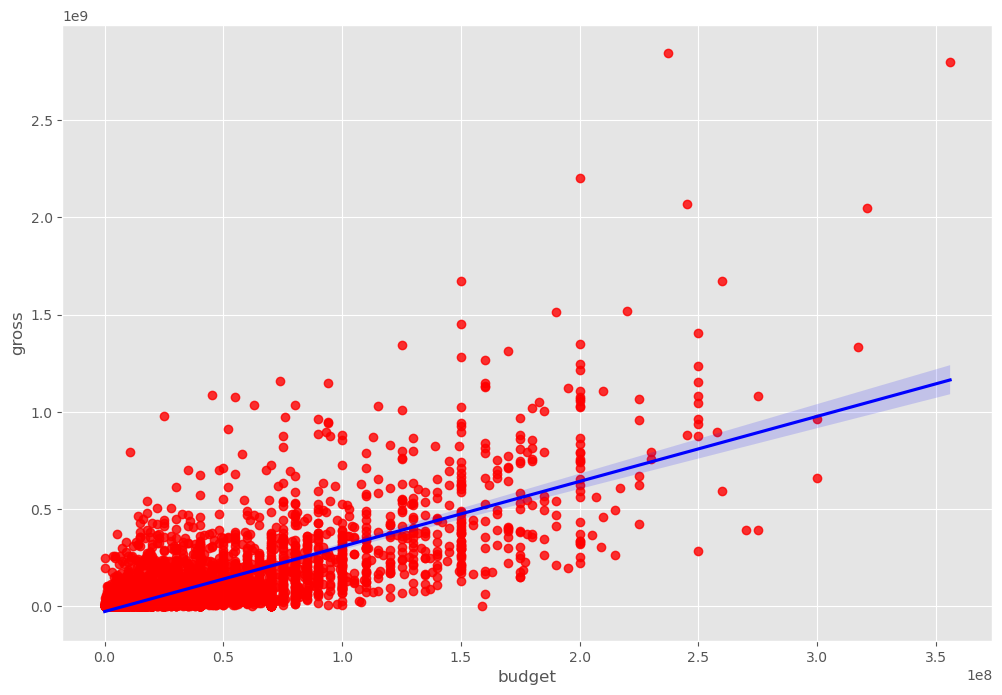

In [89]:
# Plot budget vs gross using seaborn
sns.regplot(x=df['budget'], y=df['gross'], scatter_kws={'color': 'red'}, line_kws={'color': 'blue'})

In [93]:
# Correlation between budget and gross
df[['budget', 'gross']].corr(method='pearson')# Pearson

,budget,gross
budget,1.000000,0.737691
gross,0.737691,1.000000


In [68]:
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

print(sorted_pairs)

,budget,gross
budget,1.00000,0.40056
gross,0.40056,1.00000


In [69]:
df[['budget', 'gross']].corr(method='spearman')# Spearman

,budget,gross
budget,1.000000,0.556615
gross,0.556615,1.000000


In [72]:
# Budget has a high correlation with gross revenue - Right!

In [74]:
# Correlation between numerical features
df.select_dtypes(include=['int64', 'float64']).corr()

,year,score,votes,budget,gross,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min
year,1.000000,0.091821,0.215740,0.291070,0.257486,0.114672,0.997499,0.247163,0.237084,0.008807,0.231698
score,0.091821,1.000000,0.413096,0.058154,0.186258,0.397314,0.099560,0.131832,-0.000998,0.003550,0.408680
votes,0.215740,0.413096,1.000000,0.452691,0.630757,0.309541,0.211400,0.479554,0.311093,0.021304,0.977358
budget,0.291070,0.058154,0.452691,1.000000,0.737691,0.263869,0.283617,0.515816,0.751316,-0.014495,0.434944
gross,0.257486,0.186258,0.630757,0.737691,1.000000,0.245221,0.250514,0.580479,0.476290,0.020442,0.615592
runtime,0.114672,0.397314,0.309541,0.263869,0.245221,1.000000,0.114380,0.221080,0.270572,-0.019023,0.214895
release_year_parsed,0.997499,0.099560,0.211400,0.283617,0.250514,0.114380,1.000000,0.231289,0.228187,0.010432,0.226989
log_gross,0.247163,0.131832,0.479554,0.515816,0.580479,0.221080,0.231289,1.000000,0.484619,0.028228,0.500504
log_budget,0.237084,-0.000998,0.311093,0.751316,0.476290,0.270572,0.228187,0.484619,1.000000,-0.103696,0.299570
budget_ratio,0.008807,0.003550,0.021304,-0.014495,0.020442,-0.019023,0.010432,0.028228,-0.103696,1.000000,0.031186


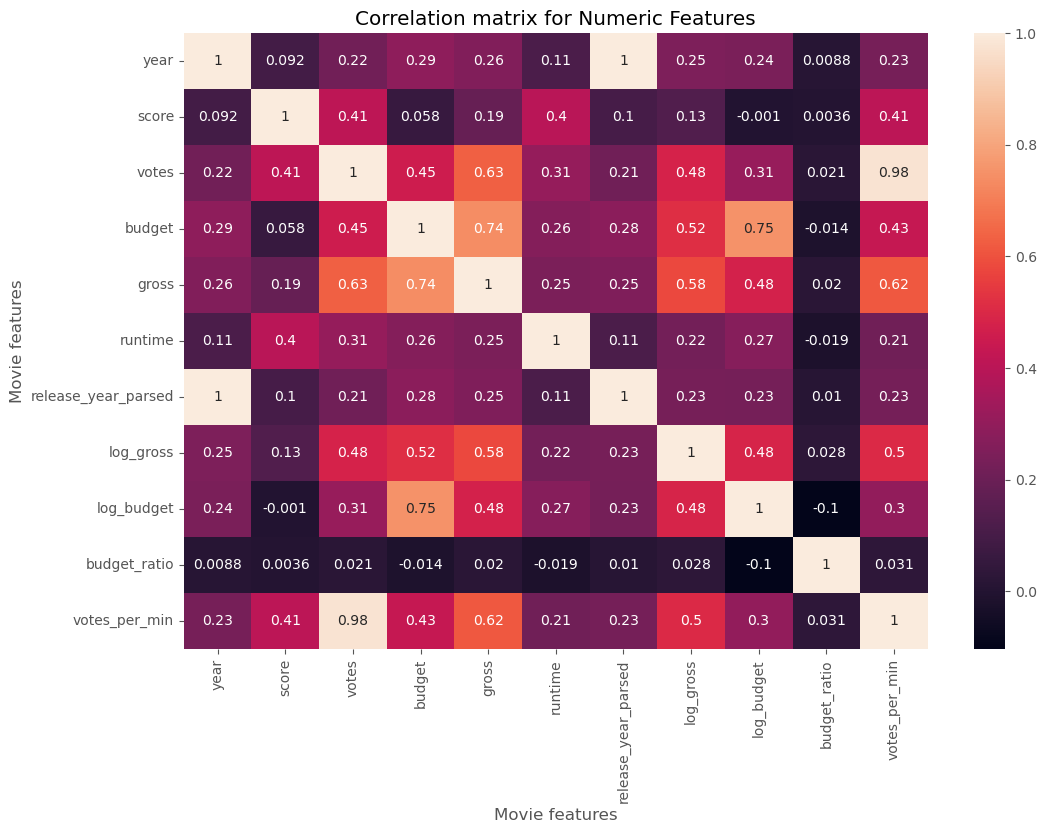

In [75]:
# Create a Correlation Heatmap of Movie Features
correlation_matrix=df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')
sns.heatmap(data=correlation_matrix,annot=True)
plt.title("Correlation matrix for Numeric Features")
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

In [94]:
# Using factorize - this assigns a random numeric value for each unique categorical value

df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

,name,rating,genre,year,released,score,votes,director,writer,star,...,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect
name,1.000000,0.337819,0.138256,0.227433,0.649544,0.098301,0.587142,0.709672,0.775155,0.637025,...,0.343416,0.979595,0.673370,0.067427,0.221973,0.979595,0.343416,0.979592,0.837117,0.221973
rating,0.337819,1.000000,-0.010436,0.028516,0.258249,-0.076266,0.134140,0.260999,0.285756,0.271519,...,0.191695,0.344039,0.303453,0.018223,0.022578,0.344039,0.191695,0.344031,0.271897,0.022578
genre,0.138256,-0.010436,1.000000,0.087065,0.088414,0.057646,0.154617,0.092636,0.087396,0.099373,...,0.218022,0.135172,0.056860,0.004357,0.082700,0.135172,0.218022,0.135119,0.133121,0.082700
year,0.227433,0.028516,0.087065,1.000000,0.303616,0.067254,0.309787,0.142053,0.182639,0.197400,...,0.139916,0.239570,0.085684,0.028670,0.941417,0.239570,0.139916,0.239529,0.283785,0.941417
released,0.649544,0.258249,0.088414,0.303616,1.000000,0.064763,0.440376,0.488924,0.533705,0.454662,...,0.258539,0.661993,0.446959,0.039038,0.306053,0.661993,0.258539,0.661963,0.579193,0.306053
score,0.098301,-0.076266,0.057646,0.067254,0.064763,1.000000,0.225088,0.138350,0.092594,0.092643,...,-0.001714,0.103430,0.018884,0.038087,0.074032,0.103430,-0.001714,0.103394,0.138261,0.074032
votes,0.587142,0.134140,0.154617,0.309787,0.440376,0.225088,1.000000,0.473205,0.504194,0.425738,...,0.204258,0.601605,0.366527,0.065243,0.304284,0.601605,0.204258,0.601544,0.616505,0.304284
director,0.709672,0.260999,0.092636,0.142053,0.488924,0.138350,0.473205,1.000000,0.680123,0.554864,...,0.258659,0.725419,0.592530,0.072649,0.139248,0.725419,0.258659,0.725431,0.627749,0.139248
writer,0.775155,0.285756,0.087396,0.182639,0.533705,0.092594,0.504194,0.680123,1.000000,0.564336,...,0.270655,0.790062,0.595392,0.049740,0.178291,0.790062,0.270655,0.790068,0.684084,0.178291
star,0.637025,0.271519,0.099373,0.197400,0.454662,0.092643,0.425738,0.554864,0.564336,1.000000,...,0.275092,0.652123,0.545846,0.069760,0.194277,0.652123,0.275092,0.652152,0.579872,0.194277


In [77]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,...,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,...,237000000.0,2.847246e+09,Twentieth Century Fox,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,356000000.0,2.797501e+09,Marvel Studios,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,...,200000000.0,2.201647e+09,Twentieth Century Fox,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,...,245000000.0,2.069522e+09,Lucasfilm,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,321000000.0,2.048360e+09,Marvel Studios,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,2018


In [78]:
# Change the objects to categories
df_numerized = df.copy()
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes# Convert categorical strings to numerical codes
df_numerized.head()

,name,rating,genre,year,released,score,votes,director,writer,star,...,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect
5445,519,4,0,2009,683,7.8,1100000.0,1116,1719,2233,...,237000000.0,2.847246e+09,2148,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,29
7445,521,4,0,2019,179,8.4,903000.0,161,717,2141,...,356000000.0,2.797501e+09,1532,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,39
3045,6727,4,6,1997,691,7.8,1100000.0,1116,1719,1524,...,200000000.0,2.201647e+09,2148,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,17
6663,5008,4,0,2015,685,7.8,876000.0,1086,2468,504,...,245000000.0,2.069522e+09,1470,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,35
7244,522,4,0,2018,188,8.4,897000.0,161,717,2141,...,321000000.0,2.048360e+09,1532,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,38


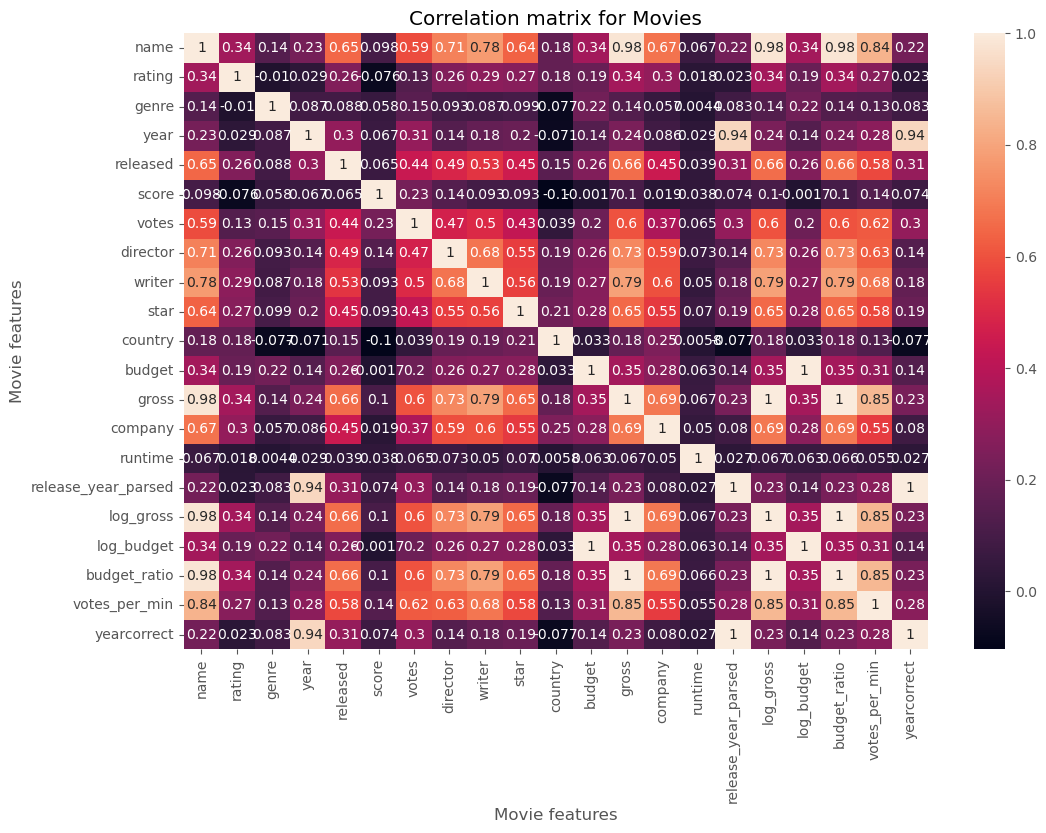

In [95]:
# Create a Correlation Heatmap of Movie Features
correlation_matrix = df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation matrix for Movies")

plt.xlabel("Movie features")

plt.ylabel("Movie features")

plt.show()

In [83]:
df_numerized.corr(method='pearson')

,name,rating,genre,year,released,score,votes,director,writer,star,...,budget,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect
name,1.000000,-0.014055,0.017885,0.007404,-0.011033,0.015473,0.011429,0.009092,0.008008,0.007278,...,0.018083,0.005557,0.008155,0.009138,0.006891,-0.003363,0.010448,0.004794,0.009201,0.006891
rating,-0.014055,1.000000,0.087769,0.021288,0.015120,-0.004147,0.039702,0.015045,-0.003566,0.004156,...,-0.142854,-0.113368,-0.044680,0.074355,0.019618,-0.044708,-0.144743,0.012665,0.025747,0.019618
genre,0.017885,0.087769,1.000000,-0.082252,0.026804,0.046093,-0.149289,-0.016412,0.008231,-0.002322,...,-0.384368,-0.243059,-0.074570,-0.040984,-0.077869,-0.263632,-0.369436,0.032814,-0.151457,-0.077869
year,0.007404,0.021288,-0.082252,1.000000,0.002465,0.091821,0.215740,-0.019116,-0.008780,-0.032319,...,0.291070,0.257486,-0.014883,0.114672,0.997499,0.247163,0.237084,0.008807,0.231698,0.997499
released,-0.011033,0.015120,0.026804,0.002465,1.000000,0.044301,0.018043,-0.002315,-0.002699,0.015812,...,0.015418,0.002341,-0.007031,0.000615,-0.001913,-0.041032,0.004107,0.011700,0.021296,-0.001913
score,0.015473,-0.004147,0.046093,0.091821,0.044301,1.000000,0.413096,0.008810,0.018648,0.000310,...,0.058154,0.186258,-0.001107,0.397314,0.099560,0.131832,-0.000998,0.003550,0.408680,0.099560
votes,0.011429,0.039702,-0.149289,0.215740,0.018043,0.413096,1.000000,0.000919,0.000972,-0.021274,...,0.452691,0.630757,0.131020,0.309541,0.211400,0.479554,0.311093,0.021304,0.977358,0.211400
director,0.009092,0.015045,-0.016412,-0.019116,-0.002315,0.008810,0.000919,1.000000,0.297601,0.036794,...,0.000194,-0.014490,0.004213,0.016941,-0.018896,0.016973,-0.004487,0.004196,0.000989,-0.018896
writer,0.008008,-0.003566,0.008231,-0.008780,-0.002699,0.018648,0.000972,0.297601,1.000000,0.023374,...,-0.027327,-0.023574,0.005972,-0.002848,-0.008979,-0.002008,-0.009281,0.003964,0.002608,-0.008979
star,0.007278,0.004156,-0.002322,-0.032319,0.015812,0.000310,-0.021274,0.036794,0.023374,1.000000,...,-0.019435,-0.002602,0.007518,0.009226,-0.033085,-0.014950,-0.011685,-0.001299,-0.020822,-0.033085


In [96]:
correlation_mat = df.apply(lambda x: x.factorize()[0]).corr()

corr_pairs = correlation_mat.unstack()

print(corr_pairs)

name         name             1.000000
             rating           0.337819
             genre            0.138256
             year             0.227433
             released         0.649544
                                ...   
yearcorrect  log_gross        0.234015
             log_budget       0.135737
             budget_ratio     0.233973
             votes_per_min    0.277167
             yearcorrect      1.000000
Length: 441, dtype: float64


In [97]:
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

print(sorted_pairs)

country      score         -0.103504
score        country       -0.103504
country      genre         -0.076930
genre        country       -0.076930
yearcorrect  country       -0.076674
                              ...   
log_gross    gross          1.000000
             log_gross      1.000000
log_budget   budget         1.000000
budget       log_budget     1.000000
yearcorrect  yearcorrect    1.000000
Length: 441, dtype: float64


In [88]:
# Looking at the ones that have a high correlation (> 0.5)

strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]

print(strong_pairs)

genre                budget                -0.384368
budget               genre                 -0.384368
genre                log_budget            -0.369436
log_budget           genre                 -0.369436
log_gross            genre                 -0.263632
                                              ...   
log_budget           log_budget             1.000000
star                 star                   1.000000
yearcorrect          yearcorrect            1.000000
                     release_year_parsed    1.000000
release_year_parsed  yearcorrect            1.000000
Length: 441, dtype: float64

In [98]:
 # Looking at the top 15 compaies by gross revenue

CompanyGrossSum = df.groupby('company')[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values('gross', ascending = False)[:15]

CompanyGrossSumSorted = CompanyGrossSumSorted['gross'].astype('int64') 

CompanyGrossSumSorted

company
Warner Bros.                 56491421806
Universal Pictures           52514188890
Columbia Pictures            43008941346
Paramount Pictures           40493607415
Twentieth Century Fox        40257053857
Walt Disney Pictures         36327887792
New Line Cinema              19883797684
Marvel Studios               15065592411
DreamWorks Animation         11873612858
Touchstone Pictures          11795832638
Dreamworks Pictures          11635441081
Metro-Goldwyn-Mayer (MGM)     9230230105
Summit Entertainment          8373718838
Pixar Animation Studios       7886344526
Fox 2000 Pictures             7443502667
Name: gross, dtype: int64

In [99]:
df['Year'] = df['released'].astype(str).str[:4]
df

,name,rating,genre,year,released,score,votes,director,writer,star,...,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect,Year
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,...,2.847246e+09,Twentieth Century Fox,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,2009,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,2.797501e+09,Marvel Studios,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,2019,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,...,2.201647e+09,Twentieth Century Fox,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,1997,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,...,2.069522e+09,Lucasfilm,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,2015,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,2.048360e+09,Marvel Studios,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,2018,Apri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,2000,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,...,1.400000e+03,British Broadcasting Corporation (BBC),103.0,2001.0,7.244942,16.648724,0.000082,50.000000,2001,Febr
7625,The Untold Story,Other,Comedy,2019,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,...,7.900000e+02,Visual Arts Entertainment,104.0,2019.0,6.673298,16.648724,0.000046,3.047619,2019,Janu
7580,Run with the Hunted,Other,Crime,2019,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,...,6.820000e+02,Roxwell Films,93.0,2020.0,6.526495,16.523561,0.000045,7.819149,2020,June
2417,Madadayo,Other,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,...,5.960000e+02,DENTSU Music And Entertainment,134.0,1993.0,6.391917,16.292049,0.000050,37.777778,1993,Apri


In [101]:
df.groupby(['company', 'year'])[["gross"]].sum()

,,gross
company,year,
"""DIA"" Productions GmbH & Co. KG",2003,44350926.0
"""Weathering With You"" Film Partners",2019,193457467.0
.406 Production,1996,10580.0
1+2 Seisaku Iinkai,2000,1196218.0
10 West Studios,2010,814906.0
...,...,...
i am OTHER,2015,17986781.0
i5 Films,2001,10031529.0
iDeal Partners Film Fund,2013,506303.0


In [102]:
CompanyGrossSum = df.groupby(['company', 'year'])[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values(['gross','company','year'], ascending = False)[:15]

CompanyGrossSumSorted = CompanyGrossSumSorted['gross'].astype('int64') 

CompanyGrossSumSorted

company                year
Walt Disney Pictures   2019    5773131804
Marvel Studios         2018    4018631866
Universal Pictures     2015    3834354888
Twentieth Century Fox  2009    3793491246
Walt Disney Pictures   2017    3789382071
Paramount Pictures     2011    3565705182
Warner Bros.           2010    3300479986
                       2011    3223799224
Walt Disney Pictures   2010    3104474158
Paramount Pictures     2014    3071298586
Columbia Pictures      2006    2934631933
                       2019    2932757449
Marvel Studios         2019    2797501328
Warner Bros.           2018    2774168962
Columbia Pictures      2011    2738363306
Name: gross, dtype: int64

In [103]:
CompanyGrossSum = df.groupby(['company'])[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values(['gross','company'], ascending = False)[:15]

CompanyGrossSumSorted = CompanyGrossSumSorted['gross'].astype('int64') 

CompanyGrossSumSorted

company
Warner Bros.                 56491421806
Universal Pictures           52514188890
Columbia Pictures            43008941346
Paramount Pictures           40493607415
Twentieth Century Fox        40257053857
Walt Disney Pictures         36327887792
New Line Cinema              19883797684
Marvel Studios               15065592411
DreamWorks Animation         11873612858
Touchstone Pictures          11795832638
Dreamworks Pictures          11635441081
Metro-Goldwyn-Mayer (MGM)     9230230105
Summit Entertainment          8373718838
Pixar Animation Studios       7886344526
Fox 2000 Pictures             7443502667
Name: gross, dtype: int64

In [104]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,...,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect,Year
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,...,2.847246e+09,Twentieth Century Fox,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,2009,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,2.797501e+09,Marvel Studios,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,2019,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,...,2.201647e+09,Twentieth Century Fox,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,1997,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,...,2.069522e+09,Lucasfilm,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,2015,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,...,2.048360e+09,Marvel Studios,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,2018,Apri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,2000,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,...,1.400000e+03,British Broadcasting Corporation (BBC),103.0,2001.0,7.244942,16.648724,0.000082,50.000000,2001,Febr
7625,The Untold Story,Other,Comedy,2019,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,...,7.900000e+02,Visual Arts Entertainment,104.0,2019.0,6.673298,16.648724,0.000046,3.047619,2019,Janu
7580,Run with the Hunted,Other,Crime,2019,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,...,6.820000e+02,Roxwell Films,93.0,2020.0,6.526495,16.523561,0.000045,7.819149,2020,June
2417,Madadayo,Other,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,...,5.960000e+02,DENTSU Music And Entertainment,134.0,1993.0,6.391917,16.292049,0.000050,37.777778,1993,Apri


In [108]:
df_numerized = df


for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name]= df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
        
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,...,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect,Year
5445,519,4,0,2009,683,7.8,1100000.0,1116,1719,2233,...,2.847246e+09,2148,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,29,9
7445,521,4,0,2019,179,8.4,903000.0,161,717,2141,...,2.797501e+09,1532,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,39,7
3045,6727,4,6,1997,691,7.8,1100000.0,1116,1719,1524,...,2.201647e+09,2148,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,17,9
6663,5008,4,0,2015,685,7.8,876000.0,1086,2468,504,...,2.069522e+09,1470,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,35,9
7244,522,4,0,2018,188,8.4,897000.0,161,717,2141,...,2.048360e+09,1532,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,38,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,3268,5,4,2000,1097,6.5,5200.0,711,1085,2218,...,1.400000e+03,463,103.0,2001.0,7.244942,16.648724,0.000082,50.000000,21,10
7625,6559,2,4,2019,1125,5.7,320.0,2459,2483,1830,...,7.900000e+02,2202,104.0,2019.0,6.673298,16.648724,0.000046,3.047619,39,11
7580,4540,2,5,2019,1796,5.2,735.0,1403,2135,2177,...,6.820000e+02,1901,93.0,2020.0,6.526495,16.523561,0.000045,7.819149,40,13
2417,3309,2,6,1993,83,7.3,5100.0,33,1660,2453,...,5.960000e+02,764,134.0,1993.0,6.391917,16.292049,0.000050,37.777778,13,7


In [109]:
df_numerized.corr(method='pearson')

,name,rating,genre,year,released,score,votes,director,writer,star,...,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect,Year
name,1.000000,-0.014055,0.017885,0.007404,-0.011033,0.015473,0.011429,0.009092,0.008008,0.007278,...,0.005557,0.008155,0.009138,0.006891,-0.003363,0.010448,0.004794,0.009201,0.006891,-0.012506
rating,-0.014055,1.000000,0.087769,0.021288,0.015120,-0.004147,0.039702,0.015045,-0.003566,0.004156,...,-0.113368,-0.044680,0.074355,0.019618,-0.044708,-0.144743,0.012665,0.025747,0.019618,0.013988
genre,0.017885,0.087769,1.000000,-0.082252,0.026804,0.046093,-0.149289,-0.016412,0.008231,-0.002322,...,-0.243059,-0.074570,-0.040984,-0.077869,-0.263632,-0.369436,0.032814,-0.151457,-0.077869,0.024940
year,0.007404,0.021288,-0.082252,1.000000,0.002465,0.091821,0.215740,-0.019116,-0.008780,-0.032319,...,0.257486,-0.014883,0.114672,0.997499,0.247163,0.237084,0.008807,0.231698,0.997499,0.000252
released,-0.011033,0.015120,0.026804,0.002465,1.000000,0.044301,0.018043,-0.002315,-0.002699,0.015812,...,0.002341,-0.007031,0.000615,-0.001913,-0.041032,0.004107,0.011700,0.021296,-0.001913,0.995717
score,0.015473,-0.004147,0.046093,0.091821,0.044301,1.000000,0.413096,0.008810,0.018648,0.000310,...,0.186258,-0.001107,0.397314,0.099560,0.131832,-0.000998,0.003550,0.408680,0.099560,0.042872
votes,0.011429,0.039702,-0.149289,0.215740,0.018043,0.413096,1.000000,0.000919,0.000972,-0.021274,...,0.630757,0.131020,0.309541,0.211400,0.479554,0.311093,0.021304,0.977358,0.211400,0.018509
director,0.009092,0.015045,-0.016412,-0.019116,-0.002315,0.008810,0.000919,1.000000,0.297601,0.036794,...,-0.014490,0.004213,0.016941,-0.018896,0.016973,-0.004487,0.004196,0.000989,-0.018896,-0.001488
writer,0.008008,-0.003566,0.008231,-0.008780,-0.002699,0.018648,0.000972,0.297601,1.000000,0.023374,...,-0.023574,0.005972,-0.002848,-0.008979,-0.002008,-0.009281,0.003964,0.002608,-0.008979,-0.003428
star,0.007278,0.004156,-0.002322,-0.032319,0.015812,0.000310,-0.021274,0.036794,0.023374,1.000000,...,-0.002602,0.007518,0.009226,-0.033085,-0.014950,-0.011685,-0.001299,-0.020822,-0.033085,0.015074


In [118]:
cat_columns = ['name', 'rating', 'genre', 'released', 'director',
               'writer', 'star', 'country', 'company']
df[cat_columns] = df[cat_columns].astype('string')

for col in cat_columns:
    df[col] = df[col].astype('category').cat.codes

df

,name,rating,genre,year,released,score,votes,director,writer,star,...,gross,company,runtime,release_year_parsed,log_gross,log_budget,budget_ratio,votes_per_min,yearcorrect,Year
5445,4065,4,0,2009,2192,7.8,1100000.0,358,4178,417,...,2.847246e+09,312,162.0,2009.0,21.769618,19.283571,12.013697,6748.466258,29,9
7445,4091,4,0,2019,3188,8.4,903000.0,2492,3428,304,...,2.797501e+09,1828,181.0,2019.0,21.751992,19.690441,7.858150,4961.538462,39,7
3045,5963,4,6,1997,2202,7.8,1100000.0,358,4178,2232,...,2.201647e+09,312,194.0,1997.0,21.512472,19.113828,11.008236,5641.025641,17,9
6663,3842,4,0,2015,2194,7.8,876000.0,2824,707,1273,...,2.069522e+09,1752,138.0,2015.0,21.450583,19.316769,8.447027,6302.158273,35,9
7244,4103,4,0,2018,3299,8.4,897000.0,2492,3428,304,...,2.048360e+09,1828,149.0,2018.0,21.440305,19.586952,6.381183,5980.000000,38,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,1694,5,4,2000,114,6.5,5200.0,1699,4374,398,...,1.400000e+03,760,103.0,2001.0,7.244942,16.648724,0.000082,50.000000,21,10
7625,5755,2,4,2019,469,5.7,320.0,695,726,2610,...,7.900000e+02,381,104.0,2019.0,6.673298,16.648724,0.000046,3.047619,39,11
7580,3264,2,5,2019,3196,5.2,735.0,2238,297,348,...,6.820000e+02,9,93.0,2020.0,6.526495,16.523561,0.000045,7.819149,40,13
2417,1744,2,6,1993,2374,7.3,5100.0,1229,4105,688,...,5.960000e+02,1132,134.0,1993.0,6.391917,16.292049,0.000050,37.777778,13,7


In [ ]:
sns.stripplot(x="rating", y="gross", data=df)
